# Split PROTACs Using Graph Algorithms

## Setup

In [375]:
from rdkit import Chem
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import os
import pandas as pd

data_dir = os.path.join(os.getcwd(), '..', 'data')

held_out_df = pd.read_csv(os.path.join(data_dir, 'processed', 'mapped_protacs_with_manually_mapped.csv')).reset_index(drop=True)
print(f'Number of mapped PROTACs: {len(held_out_df):,}')

# Remove all entries with empty linker, i.e., [*:1][*:2] or [*:2][*:1]
held_out_df = held_out_df[~held_out_df['Linker SMILES with direction'].str.contains(r'\[\*\:1\]\[\*\:2\]|\[\*\:2\]\[\*\:1\]')]

# Double check if there are any empty linkers
for smi in held_out_df['Linker SMILES with direction']:
    if smi in ['[*:1][*:2]', '[*:2][*:1]']:
        print(smi)

print(f'Number of mapped PROTACs: {len(held_out_df):,} (after removing empty linkers)')

Number of mapped PROTACs: 5,679
Number of mapped PROTACs: 5,672 (after removing empty linkers)


In [374]:
train_df = pd.read_csv(os.path.join(data_dir, 'generated', 'generated_train_protacs.csv'))
val_df = pd.read_csv(os.path.join(data_dir, 'generated', 'generated_val_protacs.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'generated', 'generated_test_protacs.csv'))
print(f'Number of generated PROTACs per train set: {len(train_df):,}')
print(f'Number of generated PROTACs per val set: {len(val_df):,}')
print(f'Number of generated PROTACs per test set: {len(test_df):,}')

Number of generated PROTACs per train set: 1,298,401
Number of generated PROTACs per val set: 11,330
Number of generated PROTACs per test set: 11,308


## Finde Representative E3

We will use Tanimoto similarity to distinguish fragments of PROTACs: if one is more similar to the representatives, then it's an E3 ligase and the other is the warhead.

In [515]:
from tqdm import tqdm
from rdkit.Chem import rdFingerprintGenerator
from protac_splitter.chemoinformatics import remove_dummy_atoms

def get_fp(smiles: str, fp_generator, return_np = True):
    """
    Get the Morgan fingerprint of a molecule from its SMILES representation.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = fp_generator.GetFingerprint(mol)
    if return_np:
        return np.array(fp)
    else:
        return fp

# Get the fingerprints:
morgan_fp_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=16,
    fpSize=1024,
    useBondTypes=True,
    includeChirality=True,
)

# fp_dict = {smi: get_fp(remove_dummy_atoms(smi), morgan_fp_generator) for smi in train_df['E3 Binder SMILES with direction']}
fp_dict = {}
for smi in tqdm(train_df['E3 Binder SMILES with direction'].unique()):
    fp = get_fp(remove_dummy_atoms(smi), morgan_fp_generator)
    if fp is not None:
        fp_dict[smi] = fp

fp_list = list(fp_dict.values())
fp2smiles = {fp.tobytes(): smi for smi, fp in fp_dict.items() if fp is not None}

100%|██████████| 217/217 [00:00<00:00, 881.62it/s]


In [516]:
from typing import List
from sklearn.cluster import AgglomerativeClustering, KMeans


def get_umap_clusters_fp(fp_list: List[str], n_clusters: int = 7) -> np.ndarray:
    """
    Cluster a list of SMILES strings using the umap clustering algorithm.
    From Scaffold Splits Overestimate Virtual Screening Performance
    https://arxiv.org/abs/2406.00873

    :param fp_list: List of SMILES strings
    :param n_clusters: The number of clusters to use for clustering
    :return: Array of cluster labels corresponding to each SMILES string in the input list.
    """
    ac = AgglomerativeClustering(n_clusters=n_clusters)
    ac.fit_predict(np.stack(fp_list))
    return ac.labels_


def get_kmeans_clusters_fp(fp_list: List[str], n_clusters: int = 10, return_centroids: bool = False) -> np.ndarray:
    """
    Cluster a list of SMILES strings using the KMeans clustering algorithm.

    :param fp_list: List of SMILES strings
    :param n_clusters: The number of clusters to use for clustering
    :return: Array of cluster labels corresponding to each SMILES string in the input list.
    """
    km = KMeans(n_clusters=n_clusters, n_init='auto', random_state=42, max_iter=1000)
    if return_centroids:
        km.fit(np.stack(fp_list))
        return km.labels_, km.cluster_centers_
    return km.fit_predict(np.stack(fp_list))

In [517]:
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import skew
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clusters(X, clusters):
    """Compute clustering metrics and assess cluster size distribution."""
    
    unique_clusters = list(set(clusters))
    
    if len(unique_clusters) < 2:  # Avoid single-cluster issues
        return {
            "silhouette": -1,
            "davies_bouldin": float("inf"),
            "calinski_harabasz": -1,
            "avg_cluster_size": len(X),
            "avg_cluster_data_ratio": 1,
            "std_cluster_size": 0,
            "min_cluster_size": len(X),
            "median_cluster_size": len(X),
            "max_cluster_size": len(X),
            "cluster_size_skewness": 0,
            "num_clusters": 1,
        }

    # Compute standard clustering metrics
    silhouette = silhouette_score(X, clusters)
    davies_bouldin = davies_bouldin_score(X, clusters)
    calinski_harabasz = calinski_harabasz_score(X, clusters)

    # Compute cluster size statistics
    cluster_sizes = [len(np.where(clusters == i)[0]) for i in np.unique(clusters)]
    avg_cluster_size = np.mean(cluster_sizes)
    avg_cluster_data_ratio = avg_cluster_size / len(X)
    std_cluster_size = np.std(cluster_sizes)
    median_cluster_size = np.median(cluster_sizes)
    min_cluster_size = np.min(cluster_sizes)
    max_cluster_size = np.max(cluster_sizes)
    cluster_size_skewness = skew(cluster_sizes, nan_policy="omit")  # Indicates imbalance in cluster sizes

    return {
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "avg_cluster_size": avg_cluster_size,
        "avg_cluster_data_ratio": avg_cluster_data_ratio,
        "std_cluster_size": std_cluster_size,
        "min_cluster_size": min_cluster_size,
        "median_cluster_size": median_cluster_size,
        "max_cluster_size": max_cluster_size,
        "cluster_size_skewness": cluster_size_skewness,
        "num_clusters": len(unique_clusters),
    }

In [518]:
centroids_dict = {}
clusters_dict = {}
metrics_df = []
for n_clusters in tqdm([10, 25, 50, 100, 150], desc="Clustering and evaluating"):
    clusters, centroids = get_kmeans_clusters_fp(fp_list, n_clusters=n_clusters, return_centroids=True)
    metrics = evaluate_clusters(fp_list, clusters)
    clusters_dict[f'kmeans_n{n_clusters}'] = clusters.copy()
    centroids_dict[n_clusters] = centroids.copy()

    metrics['num_clusters'] = n_clusters
    metrics['cluster_algorithm'] = 'kmeans'
    metrics_df.append(metrics.copy())
    
    clusters = get_umap_clusters_fp(fp_list, n_clusters=n_clusters)
    metrics = evaluate_clusters(fp_list, clusters)
    clusters_dict[f'umap_n{n_clusters}'] = clusters.copy()

    metrics['num_clusters'] = n_clusters
    metrics['cluster_algorithm'] = 'umap'
    metrics_df.append(metrics.copy())

metrics_df = pd.DataFrame(metrics_df)
metrics_df

Clustering and evaluating: 100%|██████████| 5/5 [00:01<00:00,  4.49it/s]


,silhouette,davies_bouldin,calinski_harabasz,avg_cluster_size,avg_cluster_data_ratio,std_cluster_size,min_cluster_size,median_cluster_size,max_cluster_size,cluster_size_skewness,num_clusters,cluster_algorithm
0,0.129261,2.339718,11.075803,21.60,0.100000,16.107141,4,13.5,51,0.717375,10,kmeans
1,0.130445,2.498744,11.447681,21.60,0.100000,12.745195,10,18.0,57,1.998905,10,umap
2,0.097943,2.022271,6.848378,8.64,0.040000,7.796820,1,6.0,28,1.506546,25,kmeans
3,0.143704,1.906168,8.085622,8.64,0.040000,5.520000,3,6.0,22,1.245416,25,umap
4,0.141041,1.507718,5.702807,4.32,0.020000,3.378994,1,3.5,17,1.496276,50,kmeans
5,0.177476,1.406123,6.558838,4.32,0.020000,3.120513,1,3.0,14,1.384148,50,umap
6,0.144744,0.948280,5.358977,2.16,0.010000,2.175868,1,1.0,15,3.300843,100,kmeans
7,0.193347,0.803857,5.984029,2.16,0.010000,1.770424,1,1.0,11,2.092438,100,umap
8,0.132977,0.607510,6.001038,1.44,0.006667,1.098362,1,1.0,8,3.443129,150,kmeans
9,0.161600,0.563959,6.743728,1.44,0.006667,0.883025,1,1.0,6,2.680470,150,umap


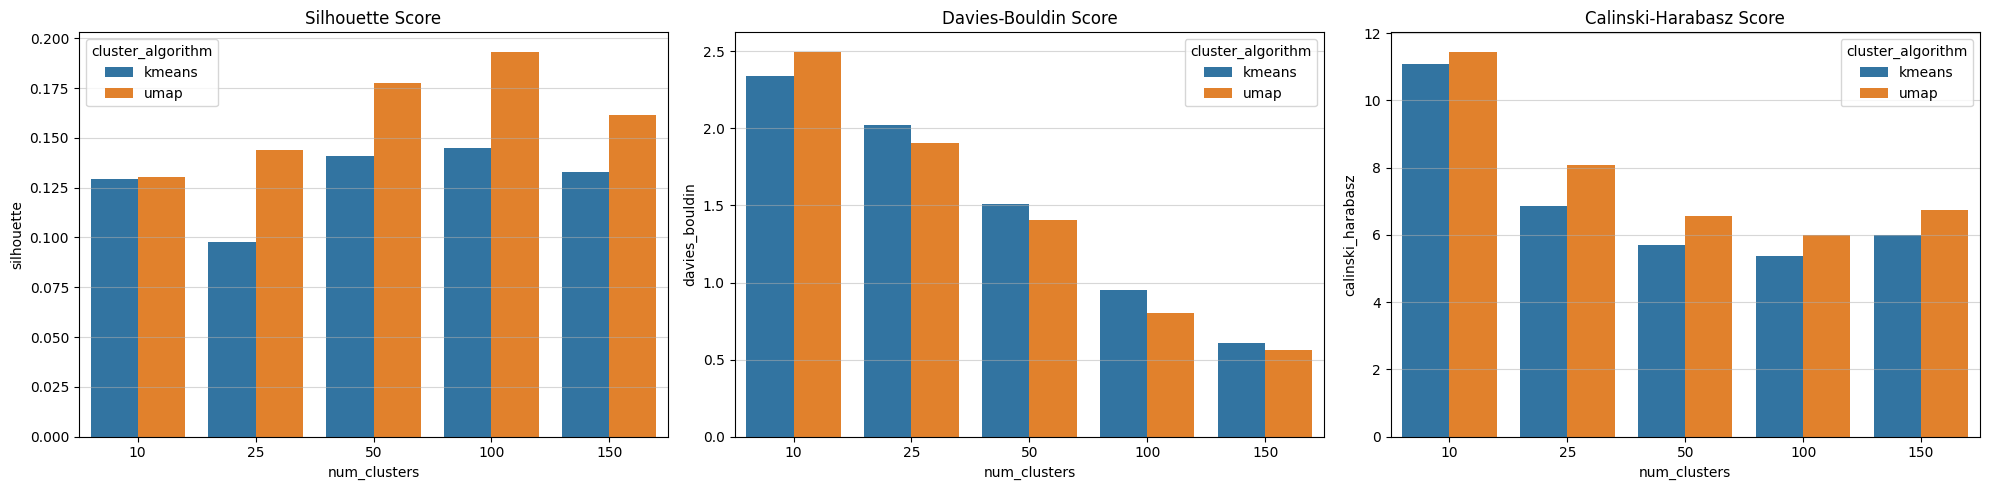

In [519]:
# Bar-plot silhouette score, Davies-Bouldin score, and Calinski-Harabasz score, hue by the clustering algorithm
fig, axs = plt.subplots(1, 3, figsize=(20, 5))
sns.barplot(data=metrics_df, x='num_clusters', y='silhouette', hue='cluster_algorithm', ax=axs[0])
axs[0].set_title('Silhouette Score')
sns.barplot(data=metrics_df, x='num_clusters', y='davies_bouldin', hue='cluster_algorithm', ax=axs[1])
axs[1].set_title('Davies-Bouldin Score')
sns.barplot(data=metrics_df, x='num_clusters', y='calinski_harabasz', hue='cluster_algorithm', ax=axs[2])
axs[2].set_title('Calinski-Harabasz Score')
plt.tight_layout()
for ax in axs:
    ax.grid(axis='y', alpha=0.5)
plt.show()

From above plots, 50 seems to be a good choice for the number of clusters.

In [520]:
# Get the centroids of the clusters
best_n_clusters = 50
centroids = centroids_dict[best_n_clusters]

# Get the cluster labels for the centroids
clusters = np.array(clusters_dict[f'kmeans_n{n_clusters}'])
representative_e3s = []
representative_e3s_fp = []
for label, centroid in enumerate(centroids):
    # Isolate the FP with the same label as the centroid
    fp_cluster = np.array(fp_list)[clusters == label]
    # Get the closest FP for the centroid, use euclidean distance
    distances = np.linalg.norm(fp_cluster - centroid, axis=1)
    closest_fp = np.argmin(distances)
    # To get the SMILES from the FP, use the fp2smiles dictionary
    closest_smiles = fp2smiles[fp_cluster[closest_fp].tobytes()]
    # Append the closest SMILES to the representative_e3s list
    representative_e3s.append(closest_smiles)
    representative_e3s_fp.append(fp_cluster[closest_fp])

# print(representative_e3s_fp)

In [521]:
from rdkit import DataStructs


def numpy_to_rdkit_fp(arr: np.ndarray) -> DataStructs.ExplicitBitVect:
    """
    Convert a NumPy array to an RDKit ExplicitBitVect.
    """
    return DataStructs.CreateFromBitString(''.join(arr.astype(str)))

representative_e3s_fp = [numpy_to_rdkit_fp(fp) for fp in representative_e3s_fp]

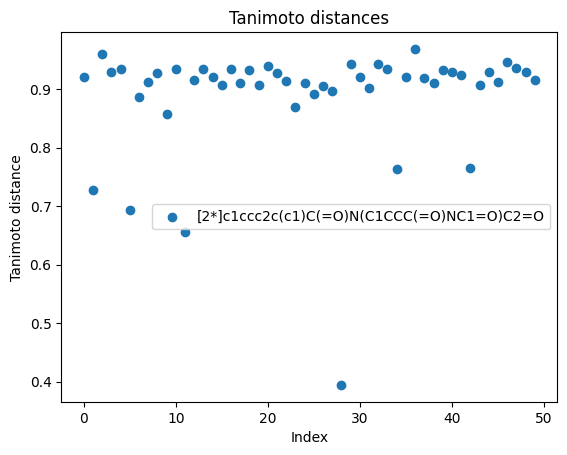

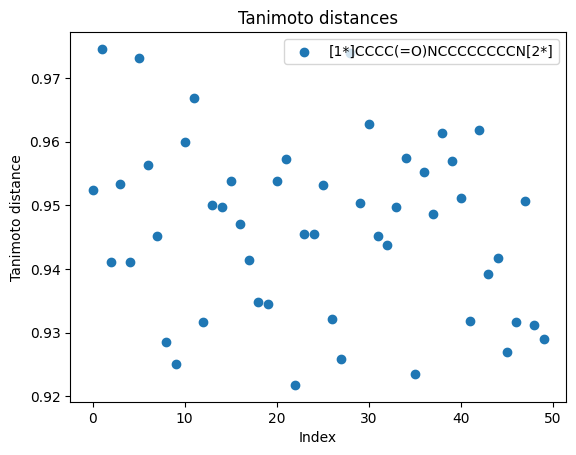

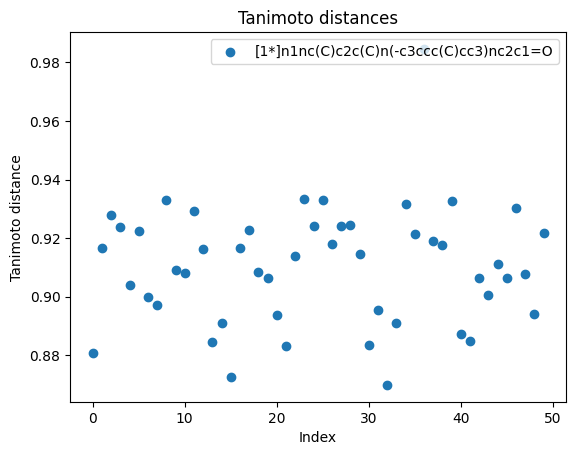

Average Tanimoto distance for E3:      0.8901141956803234
Average Tanimoto distance for Linker:  0.9464029513530192
Average Tanimoto distance for Warhead: 0.9105967829251957


In [525]:
def average_tanimoto_distance(smiles, fingerprints, morgan_fp_generator, show_plot=False):
    """
    Compute the average Tanimoto distance between a query SMILES and a list of RDKit fingerprints.

    Parameters:
        smiles (str): SMILES string of the query molecule.
        fingerprints (list): List of RDKit fingerprint objects (e.g., ExplicitBitVect).
        morgan_fp_generator: RDKit Morgan fingerprint generator.

    Returns:
        float: Average Tanimoto distance (1 - similarity) between the query and the fingerprints.
    """
    query_fp = get_fp(smiles, morgan_fp_generator, return_np=False)
    if query_fp is None:
        raise ValueError(f"Invalid SMILES string: {smiles}")
    distances = DataStructs.BulkTanimotoSimilarity(query_fp, fingerprints, returnDistance=True)

    if show_plot:
        # Scatter plot the distances
        plt.scatter(range(len(distances)), distances, label=smiles)
        plt.xlabel('Index')
        plt.ylabel('Tanimoto distance')
        plt.title('Tanimoto distances')
        plt.legend()
        plt.show()

    return np.array(distances).mean()


e3_sample = "[2*]c1ccc2c(c1)C(=O)N(C1CCC(=O)NC1=O)C2=O"
lk_sample = "[1*]CCCC(=O)NCCCCCCCCN[2*]"
wh_sample = "[1*]n1nc(C)c2c(C)n(-c3ccc(C)cc3)nc2c1=O"

# Get the average Tanimoto distance for the E3 ligands
avg_tanimoto_e3 = average_tanimoto_distance(e3_sample, representative_e3s_fp, morgan_fp_generator, show_plot=True)
avg_tanimoto_lk = average_tanimoto_distance(lk_sample, representative_e3s_fp, morgan_fp_generator, show_plot=True)
avg_tanimoto_wh = average_tanimoto_distance(wh_sample, representative_e3s_fp, morgan_fp_generator, show_plot=True)

print(f"Average Tanimoto distance for E3:      {avg_tanimoto_e3}")
print(f"Average Tanimoto distance for Linker:  {avg_tanimoto_lk}")
print(f"Average Tanimoto distance for Warhead: {avg_tanimoto_wh}")

## Graph-Based Algorithm

In [ ]:
from typing import Dict
import re
from protac_splitter.display_utils import display_mol, get_mapped_protac_img
from protac_splitter.chemoinformatics import get_atom_idx_at_attachment
from rdkit.Chem import Draw

def bond_capacity(bond):
    if bond.GetIsAromatic() or bond.IsInRing():
        return 1000  # very high capacity: avoid cutting aromatic bonds
    elif bond.GetBondType() == Chem.BondType.SINGLE:
        return 1     # low capacity: prefer to cut here
    elif bond.GetBondType() == Chem.BondType.DOUBLE:
        return 10    # medium penalty
    elif bond.GetBondType() == Chem.BondType.TRIPLE:
        return 20    # stronger penalty
    else:
        return 50    # fallback for unknown/rare types

def smiles_to_nx(smiles):
    mol = Chem.MolFromSmiles(smiles)
    G = nx.Graph()
    for atom in mol.GetAtoms():
        G.add_node(atom.GetIdx(), element=atom.GetSymbol())
    for bond in mol.GetBonds():
        capacity = bond_capacity(bond)
        G.add_edge(bond.GetBeginAtomIdx(), bond.GetEndAtomIdx(), bond_type=bond.GetBondType(), capacity=capacity)
    return G

def extract_attachment_point(smiles):
    """
    Extracts the number X from the pattern [X*] in a SMILES string.

    Parameters:
        smiles (str): The SMILES string containing the attachment point.

    Returns:
        str or None: The extracted number as a string, or None if not found.
    """
    match = re.search(r'\[(\d+)\*\]', smiles)
    return match.group(1) if match else None

def nx_split(protac_smiles, representative_e3s_fp, morgan_fp_generator, use_capacity_weight = False, betweenness_threshold = 0.4) -> Dict[str, str]:
    """
    Split the PROTAC molecule into two parts using the NetworkX library.
    
    Parameters:
        protac_smiles (str): The SMILES string of the PROTAC molecule.
        representative_e3s_fp (list): List of representative E3 ligands fingerprints.
        morgan_fp_generator: RDKit Morgan fingerprint generator (should be the same as the one that generated the E3 fingerprints).
        use_capacity_weight (bool): Whether to use bond capacity as weight for the graph.
        betweenness_threshold (float): Threshold for betweenness centrality to consider a node as a candidate for splitting.
        
    Returns:
        dict: A dictionary containing the E3 ligand, warhead, linker, top nodes, and max centrality score.
    """
    # -----------------------------------
    # Deterministic graph-based algorithm
    # -----------------------------------
    protac = Chem.MolFromSmiles(protac_smiles)
    if protac is None:
        raise ValueError(f"Invalid SMILES string: {protac_smiles}")

    G = smiles_to_nx(protac_smiles)

    # Compute betweenness centrality
    weight = 'capacity' if use_capacity_weight else None
    centrality = nx.betweenness_centrality(G, normalized=True, endpoints=True, weight=weight)

    # Get the two nodes with the highest betweenness centrality
    sorted_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)

    # Get the top two nodes
    top_nodes = [n for n, _ in sorted_nodes][:2]

    # Get the top nodes with the highest betweenness centrality that are not in
    # a ring, but are adjacent to the top nodes or have a high betweenness
    for node, score in sorted_nodes:
        # Check if the node is in a ring in the protac molecule
        atom = protac.GetAtomWithIdx(node)
        if not atom.IsInRing():
            # Check if the atom is adjacent to any of the top nodes, if so, add it to the list
            for neighbor in G.neighbors(node):
                if neighbor in top_nodes:
                    top_nodes.append(node)
                    break
            if score > betweenness_threshold:
                top_nodes.append(node)

    # If a node as only top nodes as neighbors, add it to the list
    for node in G.nodes():
        if node not in top_nodes:
            neighbors = list(G.neighbors(node))
            if all(neighbor in top_nodes for neighbor in neighbors):
                top_nodes.append(node)

    # Get all paths between the top nodes, e.g., rings
    for i in range(len(top_nodes)):
        for j in range(i + 1, len(top_nodes)):
            node1 = top_nodes[i]
            node2 = top_nodes[j]

            for path in nx.all_simple_paths(G, node1, node2):
                for node in path:
                    if node not in top_nodes:
                        top_nodes.append(node)

    # Remove duplicates
    top_nodes = list(set(top_nodes))
    
    # Loop over the top nodes and find the nodes that have a neighbor outside
    # the top nodes
    edge_nodes = set()
    for top_node in top_nodes:
        for neighbor in G.neighbors(top_node):
            if neighbor not in top_nodes:
                edge_nodes.update([(top_node, neighbor)])
                break
            
    # Get molecule fragment from the top nodes
    bonds = [protac.GetBondBetweenAtoms(i, j) for (i, j) in edge_nodes]
    bonds_idx = [bond.GetIdx() for bond in bonds if bond is not None]
    
    # Try any pair of indexes, if the number of resulting fragments is not 3,
    # then do not consider them as candidates for splitting
    candidate_bonds = []
    for i in range(len(bonds_idx)):
        for j in range(i + 1, len(bonds_idx)):
            bond1 = bonds_idx[i]
            bond2 = bonds_idx[j]

            # Get the fragments
            fragments = Chem.FragmentOnBonds(protac, [bond1, bond2])
                
            # Check if there are 3 fragments
            if Chem.MolToSmiles(fragments).count(".") == 2:
                frag_lens = []
                avg_len = 0
                for frag in Chem.GetMolFrags(fragments, asMols=True):
                    frag_len = frag.GetNumAtoms()
                    frag_lens.append(frag_len)
                    avg_len += frag_len
                avg_len /= 3

                # Calculate the standard deviation of the fragment lengths
                len_std = 0
                for frag_len in frag_lens:
                    len_std += (frag_len - avg_len) ** 2
                len_std = (len_std / 3) ** 0.5
                candidate_bonds.append(((bond1, bond2), len_std))

    # Sort the candidate bonds by distance to average (smallest first)
    candidate_bonds = sorted(candidate_bonds, key=lambda x: x[1])
    if len(candidate_bonds) > 0:
        bonds_idx = candidate_bonds[0][0]

    ligands = Chem.FragmentOnBonds(protac, bonds_idx, addDummies=True, dummyLabels=[(1, 1), (2, 2)])

    # Get the linker
    substructures = []
    for ligand in Chem.GetMolFrags(ligands, asMols=True):
        ligand_smiles = Chem.MolToSmiles(ligand, canonical=True)
        if ligand_smiles.count("*") == 2:
            linker_smiles = ligand_smiles
        else:
            substructures.append(ligand_smiles)

    sub1_dist = average_tanimoto_distance(substructures[0], representative_e3s_fp, morgan_fp_generator)
    sub2_dist = average_tanimoto_distance(substructures[1], representative_e3s_fp, morgan_fp_generator)
    if sub1_dist < sub2_dist:
        e3_smiles = substructures[0]
        wh_smiles = substructures[1]
    else:
        e3_smiles = substructures[1]
        wh_smiles = substructures[0]

    # Get the attachment point using a regex, e.g., should return 1 if [1*] is in the SMILES
    e3_attach_point = extract_attachment_point(e3_smiles)
    e3_smiles = e3_smiles.replace(f"[{e3_attach_point}*]", "[*:2]")
    linker_smiles = linker_smiles.replace(f"[{e3_attach_point}*]", "[*:2]")

    wh_attach_point = extract_attachment_point(wh_smiles)
    wh_smiles = wh_smiles.replace(f"[{wh_attach_point}*]", "[*:1]")
    linker_smiles = linker_smiles.replace(f"[{wh_attach_point}*]", "[*:1]")
    return {'e3': e3_smiles, 'poi': wh_smiles, 'linker': linker_smiles, 'top_nodes': top_nodes, 'centrality': centrality}


idx = 3765
for i in range(2, 3):
    # sample = held_out_df.sample(n=1, random_state=42 + i).iloc[0]
    sample = held_out_df.iloc[i]
    protac_smiles = sample['PROTAC SMILES']
    wh_smiles = sample['POI Ligand SMILES with direction']
    lk_smiles = sample['Linker SMILES with direction']
    e3_smiles = sample['E3 Binder SMILES with direction']

    protac = Chem.MolFromSmiles(protac_smiles)
    wh = Chem.MolFromSmiles(wh_smiles)
    lk = Chem.MolFromSmiles(lk_smiles)
    e3 = Chem.MolFromSmiles(e3_smiles)

    # display_mol(Chem.MolFromSmiles(protac_smiles), w=1500, h=600)
    get_mapped_protac_img(protac_smiles, wh_smiles, lk_smiles, e3_smiles, w=1500, h=600, display_image=True, useSVG=True)
    # wh_edge = get_atom_idx_at_attachment(protac, wh, lk)
    # e3_edge = get_atom_idx_at_attachment(protac, e3, lk)
    
    ret = nx_split(protac_smiles, representative_e3s_fp, morgan_fp_generator, use_capacity_weight=False, betweenness_threshold=0.4)
    e3_smiles = ret['e3']
    wh_smiles = ret['poi']
    linker_smiles = ret['linker']
    top_nodes = ret['top_nodes']
    centrality = ret['centrality']

    display_mol(Chem.MolFromSmiles(e3_smiles), w=800, h=400, legend="E3")
    display_mol(Chem.MolFromSmiles(linker_smiles), w=800, h=400, legend="Linker")
    display_mol(Chem.MolFromSmiles(wh_smiles), w=800, h=400, legend="WH")

    display(Draw.MolToImage(
        protac,
        size=(1500, 400),
        highlightColor=(1, 0, 1, 0.3), # Light purple
        highlightAtoms=top_nodes, # Highlight the top nodes
        legend=f"Graph nodes: {top_nodes} (Betweenness centrality: {centrality[top_nodes[0]]:.3f})",
    ))



def get_predictions(row):
    """
    Get the predictions for a given row of the dataframe.
    """
    ret = nx_split(row['PROTAC SMILES'], representative_e3s_fp, morgan_fp_generator, use_capacity_weight=False, betweenness_threshold=0.4)
    row['POI Ligand SMILES with direction'] = ret['e3']
    row['Linker SMILES with direction'] = ret['poi']
    row['E3 Binder SMILES with direction'] = ret['linker']
    return row

# Apply the function to the dataframe
tqdm.pandas(desc="Getting predictions")
nx_predictions_df = held_out_df.progress_apply(get_predictions, axis=1)

---

## Possible Ideas for the Future

Bridges found: [(0, 1), (7, 8), (11, 12), (12, 13), (22, 23), (26, 27), (27, 28), (28, 29), (29, 30), (30, 31), (31, 32), (32, 33), (33, 34), (34, 35), (35, 36), (36, 37), (37, 38), (38, 39), (38, 40), (40, 41), (47, 48), (49, 50), (53, 54), (56, 57), (58, 59)]


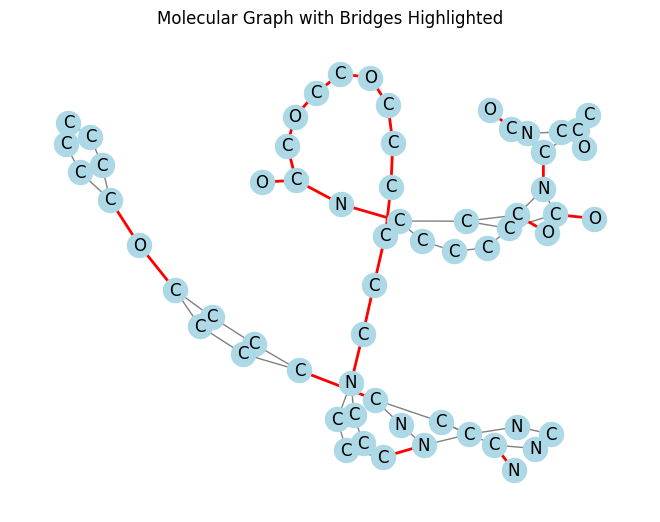

In [290]:
def find_bridges(G):
    return list(nx.bridges(G))

def visualize_graph(G, bridges):
    pos = nx.spring_layout(G)
    elements = nx.get_node_attributes(G, 'element')
    nx.draw(G, pos, with_labels=True, labels=elements, node_color='lightblue', edge_color='gray')
    nx.draw_networkx_edges(G, pos, edgelist=bridges, edge_color='red', width=2)
    plt.title("Molecular Graph with Bridges Highlighted")
    plt.show()

G = smiles_to_nx(protac_smiles)
bridges = find_bridges(G)
print("Bridges found:", bridges)
visualize_graph(G, bridges)

In [291]:
from networkx.algorithms.flow import (
    shortest_augmenting_path,
    preflow_push,
    dinitz,
    edmonds_karp,
    boykov_kolmogorov,
    capacity_scaling,
)


def find_min_cut(G, source, target):
    cut_value, partition = nx.minimum_cut(G, source, target, capacity='capacity')
    reachable, non_reachable = partition
    cutset = set()
    for u in reachable:
        for v in G[u]:
            if v in non_reachable:
                cutset.add((u, v))
    return cut_value, cutset

def construct_gomory_hu_tree(G):
    return nx.gomory_hu_tree(G, capacity='capacity')

def min_cut_from_gomory_hu(T, u, v):
    path = nx.shortest_path(T, u, v, weight='weight')
    min_weight = float('inf')
    min_edge = None
    for i in range(len(path) - 1):
        weight = T[path[i]][path[i+1]]['weight']
        if weight < min_weight:
            min_weight = weight
            min_edge = (path[i], path[i+1])
    return min_weight, min_edge

protac = Chem.MolFromSmiles(protac_smiles)
# Get the number of atoms in the molecule
num_atoms = protac.GetNumAtoms()
print(f'Number of atoms in the molecule: {num_atoms}')

G = smiles_to_nx(protac_smiles)

# Apply Minimum Cut between two nodes (e.g., 0 and num_atoms-1)
cut_value, cutset = find_min_cut(G, 0, num_atoms-1)
print("Minimum Cut Value:", cut_value)
print("Cutset Edges:", cutset)

# Construct Gomory–Hu Tree
T = construct_gomory_hu_tree(G)

# Find minimum cut between two nodes using Gomory–Hu Tree
min_weight, min_edge = min_cut_from_gomory_hu(T, 0, num_atoms-1)
print("Gomory-Hu Tree Minimum Cut Value:", min_weight)
print("Gomory-Hu Tree Cut Edge:", min_edge)

Number of atoms in the molecule: 62
Minimum Cut Value: 1
Cutset Edges: {(22, 23)}
Gomory-Hu Tree Minimum Cut Value: 1
Gomory-Hu Tree Cut Edge: (0, 1)


In [ ]:
from collections import defaultdict
import networkx as nx
import numpy as np
import community as community_louvain  # Requires the 'python-louvain' package
from rdkit import Chem
from rdkit.Chem import Draw


def detect_communities(G):
    partition = community_louvain.best_partition(G, randomize=False, weight='capacity', resolution=1)
    return partition

def compute_cut_sizes(G, partition, weight=None):
    # Organize nodes by their partition
    communities = defaultdict(set)
    for node, comm_id in partition.items():
        communities[comm_id].add(node)
    
    # Compute cut sizes between each pair of partitions
    cut_sizes = {}
    comm_ids = list(communities.keys())
    for i in range(len(comm_ids)):
        for j in range(i + 1, len(comm_ids)):
            comm_i = communities[comm_ids[i]]
            comm_j = communities[comm_ids[j]]
            cut = nx.cut_size(G, comm_i, comm_j, weight=weight)
            cut_sizes[(comm_ids[i], comm_ids[j])] = cut
    return cut_sizes

def compute_conductance(G, partition, weight=None):
    communities = defaultdict(set)
    for node, comm_id in partition.items():
        communities[comm_id].add(node)
    
    conductance_values = {}
    comm_ids = list(communities.keys())
    for i in range(len(comm_ids)):
        for j in range(i + 1, len(comm_ids)):
            comm_i = communities[comm_ids[i]]
            comm_j = communities[comm_ids[j]]
            cond = nx.conductance(G, comm_i, T=comm_j, weight=weight)
            conductance_values[(comm_ids[i], comm_ids[j])] = cond
    return conductance_values

def compute_normalized_cut(G, partition, weight=None):
    communities = defaultdict(set)
    for node, comm_id in partition.items():
        communities[comm_id].add(node)
    
    normalized_cuts = {}
    comm_ids = list(communities.keys())
    for i in range(len(comm_ids)):
        for j in range(i + 1, len(comm_ids)):
            comm_i = communities[comm_ids[i]]
            comm_j = communities[comm_ids[j]]
            ncut = nx.normalized_cut_size(G, comm_i, T=comm_j, weight=weight)
            normalized_cuts[(comm_ids[i], comm_ids[j])] = ncut
    return normalized_cuts

def compute_balance_ratios(partition):
    from itertools import combinations
    communities = defaultdict(set)
    for node, comm_id in partition.items():
        communities[comm_id].add(node)
    
    balance_ratios = {}
    comm_ids = list(communities.keys())
    for i in range(len(comm_ids)):
        for j in range(i + 1, len(comm_ids)):
            size_i = len(communities[comm_ids[i]])
            size_j = len(communities[comm_ids[j]])
            ratio = min(size_i, size_j) / max(size_i, size_j)
            balance_ratios[(comm_ids[i], comm_ids[j])] = ratio
    return balance_ratios


def get_representative_nodes(G, partition):
    communities = {}
    for node, comm_id in partition.items():
        communities.setdefault(comm_id, []).append(node)
    
    representatives = {}
    for comm_id, nodes in communities.items():
        subgraph = G.subgraph(nodes)
        degrees = subgraph.degree()
        # Select node with highest degree
        rep_node = max(degrees, key=lambda x: x[1])[0]
        representatives[comm_id] = rep_node
    return representatives

def compute_average_edge_betweenness(G, cutset):
    betweenness = nx.edge_betweenness_centrality(G)
    return sum(betweenness[edge] for edge in cutset) / len(cutset)

def visualize_graph(G, partition, cutset):
    pos = nx.spring_layout(G)
    # Color nodes by community
    communities = set(partition.values())
    colors = plt.cm.rainbow(np.linspace(0, 1, len(communities)))
    color_map = dict(zip(communities, colors))
    node_colors = [color_map[partition[node]] for node in G.nodes()]
    
    nx.draw(G, pos, node_color=node_colors, with_labels=True, edge_color='gray')
    # Highlight cutset edges
    nx.draw_networkx_edges(G, pos, edgelist=cutset, edge_color='red', width=2)
    plt.title("Graph with Dense Regions and Connecting Chain Highlighted")
    plt.show()
    
def rank_partitions(cut_sizes, conductances, normalized_cuts, balance_ratios,
                    w_cut=1.0, w_conduct=1.0, w_ncut=1.0, w_balance=1.0):
    rankings = []
    for pair in cut_sizes:
        cut = cut_sizes[pair]
        cond = conductances.get(pair, float('inf'))
        ncut = normalized_cuts.get(pair, float('inf'))
        balance = balance_ratios.get(pair, 0.0)

        # Combine into a score: lower is better
        score = (
            w_cut * cut +
            w_conduct * cond +
            w_ncut * ncut -
            w_balance * balance  # because higher balance is better
        )
        rankings.append((pair, score))
    
    # Sort by score ascending (lower score = better partition)
    rankings.sort(key=lambda x: x[1])
    return rankings


G = smiles_to_nx(protac_smiles)
partition = detect_communities(G)

# Get the representative nodes for the top-ranked partitions
representative_nodes = get_representative_nodes(G, partition)

cut_sizes = compute_cut_sizes(G, partition)
conductances = compute_conductance(G, partition)
normalized_cuts = compute_normalized_cut(G, partition)
balance_ratios = compute_balance_ratios(partition)

# Rank partitions based on the metrics
rankings = rank_partitions(cut_sizes, conductances, normalized_cuts, balance_ratios, w_cut=1, w_conduct=1, w_ncut=1, w_balance=1)

all_nodes = set(G.nodes())
num_splits = 0

print("Top-ranked partitions:")
for (partition1, partition2), score in rankings:
    
    node1 = representative_nodes[partition1]
    node2 = representative_nodes[partition2]

    print(f"Partition Pair: {(partition1, partition2)}, Score: {score:.4f}")
    print(f"  Representative Nodes: {node1}, {node2}\n")

    cut_value, cutsets = find_min_cut(G, node1, node2)

    # Find minimum cut between two nodes using Gomory–Hu Tree
    T = construct_gomory_hu_tree(G)
    _, cutset = min_cut_from_gomory_hu(T, node1, node2)
    cutsets = [cutset]

    # Check if the tuple in the cutset is the same as the edge between E3 and WH
    for cutset in cutsets:
        if (e3_edge[0] in cutset and e3_edge[1] in cutset) or (wh_edge[0] in cutset and wh_edge[1] in cutset):
            print()
            print(f"Cutset contains the edge between E3 and WH: {cutset}")
            break

    # betweenness = compute_average_edge_betweenness(G, cutsets)
    # print(f"Cutset: {cutsets}, value: {cut_value}, betweenness: {betweenness}")

    for cutset in cutsets:
        if (e3_edge[0] in cutset and e3_edge[1] in cutset) or (wh_edge[0] in cutset and wh_edge[1] in cutset):
            print()
            break

    for cutset in cutsets:
        node1, node2 = cutset
        break

    # Ensure the splitting nodes are not the same as before
    if node1 not in all_nodes or node2 not in all_nodes:
        continue

    # Remove the representative nodes from the set of all nodes
    all_nodes.remove(node1)
    all_nodes.remove(node2)
    
    purple = (1, 0, 1, 0.3)
    display(Draw.MolToImage(
        protac,
        size=(1500, 400),
        highlightColor=purple,
        highlightAtoms=[node1, node2],
    ))

    num_splits += 1
    if num_splits >= 50:
        break